In [4]:
import numpy as np
import math
#import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
from scipy import stats

params={
    'axes.labelsize'  : '24' ,
    'axes.linewidth' : '1.2' ,
    'axes.labelweight': 'bold' ,
#    'font.weight':  'bold' , 
#    'axes.labelcolor':    'red',
# x axis
    'xtick.direction' : 'in' ,
    'xtick.major.size' : '7' ,
    'xtick.major.width' : '1.25' ,
    'xtick.minor.size' : '4.43' ,
    'xtick.minor.width' : '1.25' ,
    'xtick.minor.visible' : 'True' ,
    'xtick.top' : 'True' ,
    'xtick.labelsize' : '24' ,
    'xtick.major.pad' : '8',

 #y axis
    'ytick.direction' : 'in' ,
    'ytick.major.size' : '7' ,
    'ytick.major.width' : '1.25' ,
    'ytick.minor.size' : '4.43' ,
    'ytick.minor.width' : '1.25' ,
    'ytick.minor.visible' : 'True' ,
    'ytick.right' : 'True' ,
    'ytick.labelsize' : '24' ,
    'ytick.major.pad' : '8',

    'lines.linewidth' : '3.3' ,
#legend
    'legend.fontsize' : '18' ,
    'legend.frameon' : 'False',
    'figure.figsize'    : '8, 6',

#Figure layout
#    'figure.autolayout' : 'True' ,
    'figure.subplot.left':   '0.14 ', # the left side of the subplots of the figure
    'figure.subplot.right':  '0.85',   # the right side of the subplots of the figure
    'figure.subplot.bottom': '0.13',   # the bottom of the subplots of the figure
    'figure.subplot.top':    '0.95',   # the top of the subplots of the figure

##font size
#    'font.size' : '50',

# Use LaTeX for math formatting
    'text.usetex' : 'True',
    'text.latex.preamble' : r'\usepackage{amsmath}',
    'text.latex.preamble' : r'\usepackage{bm}'
}
pylab.rcParams.update(params)


In [5]:
istp =60000
f = open('output/uy' + str(istp) + '.dat', 'rb')
recl = np.fromfile(f, dtype='int32', count=1)
f.seek(4)
field = np.fromfile(f, dtype='float64')
print(field.shape)
# uy = field.reshape(nx, ny, nz)

(2400,)


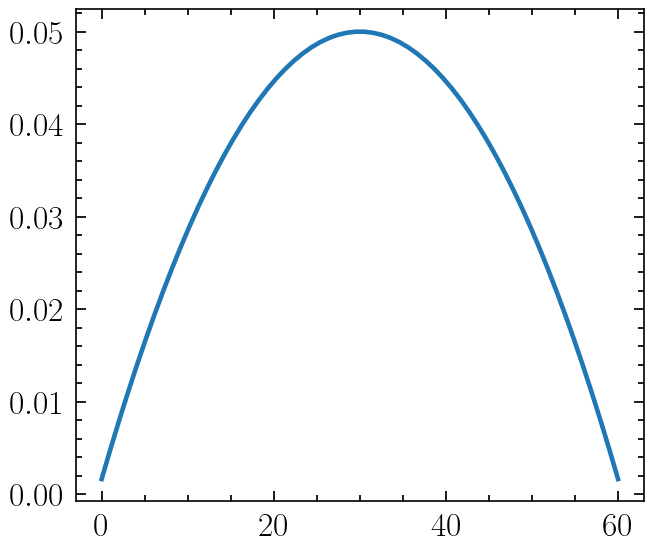

In [6]:
Re= 50.
nu = 0.05
H = 60
rho0 = 1.0

u_star = Re*nu/H
force_in_y = Re**2.*nu**2./H**3.
tau_w = u_star**2.*rho0

nx = H; ny = 20; nz = 2
data_uy = field.reshape(nx, ny, nz,order= 'F')

uymean = np.zeros(nx)
for i in range (0, nx):
    uymean[i] = np.mean(data_uy[i, :, :])

xx = np.linspace(0, nx, nx)
# xx = (xx + 0.5)*180./14120
# print(xx)
plt.plot(xx[:], uymean[:])
# plt.xscale('log')
# plt.xlim(0.5,180)

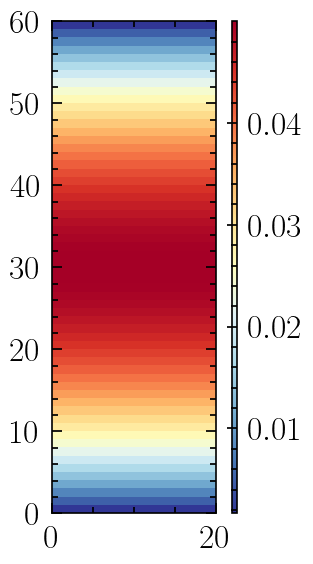

In [ ]:
from matplotlib.patches import Rectangle
def add_colorbar(im, width=None, pad=0.02, **kwargs):
    
    l, b, w, h = im.axes.get_position().bounds        # get boundaries
    width = width or 0.035 * w                        # get width of the colorbar
    pad = pad or width                                # get pad between im and cbar
    fig = im.axes.figure                              # get figure of image
    cax = fig.add_axes([l + w + pad, b, width, h])    # define cbar Axes
    return fig.colorbar(im, cax=cax, **kwargs)

xx = np.linspace(0, ny, ny+1)
yy = np.linspace(0, nx, nx+1) 
zz = np.linspace(0, nz, nz+1)
extent = [xx[0], xx[-1], yy[0], yy[-1]]
# print(xx)
fig, ax = plt.subplots()

# x-y slice
im = plt.imshow(data_uy[:,:,1], extent = extent, origin='lower', cmap='RdYlBu_r')

add_colorbar(im)

plt.savefig('test.png')
plt.show()


tt 0.3333333333333333
tt 0.6666666666666666
tt 4.0


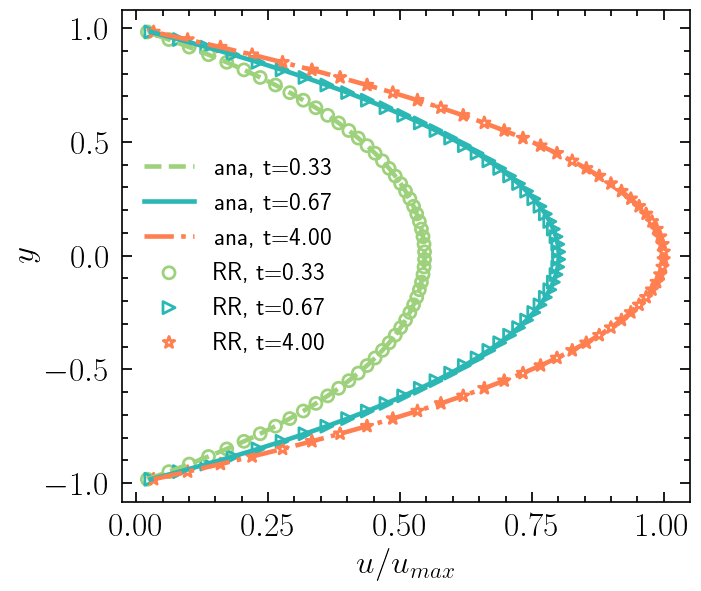

In [13]:
dir = 'output/'

nxy = nx*ny
count = 0

istep1 = 5000
istep2 = 10000
istep3 = 60000
finameu  = dir+'ux'  + str(istep1) + '.dat'
finamev  = dir+'uy'  + str(istep1) + '.dat'
finamew  = dir+'uz'  + str(istep1) + '.dat'
fnamerho = dir+'rho' + str(istep1) + '.dat'
# read uy1
f = open(finamev, 'rb')
recl = np.fromfile(f, dtype='int32', count=1)
f.seek(4)
field = np.fromfile(f, dtype='float64')
# print(field.shape)
data_v1 =  field.reshape(nx, ny, nz, order= 'F')

finamev  = dir+'uy'  + str(istep2) + '.dat'
# read uy2
f = open(finamev, 'rb')
recl = np.fromfile(f, dtype='int32', count=1)
f.seek(4)
field = np.fromfile(f, dtype='float64')
# print(field.shape)
data_v2 =  field.reshape(nx, ny, nz, order= 'F')

finamev  = dir+'uy'  + str(istep3) + '.dat'
# read uy3
f = open(finamev, 'rb')
recl = np.fromfile(f, dtype='int32', count=1)
f.seek(4)
field = np.fromfile(f, dtype='float64')
# print(field.shape)
data_v3 =  field.reshape(nx, ny, nz, order= 'F')


data_plt_v1 = data_v1[:,:,0]
data_plt_v2 = data_v2[:,:,0]
data_plt_v3 = data_v3[:,:,0]

pi = np.pi; Re = 50.; u0 = 0.05
x0 = np.linspace(-1+0.5*(2/nx), 1-0.5*(2/nx), nx)
visc = u0*nx/Re

tt = np.zeros((3))
# three different times
tt[0] = 4. * visc * istep1 / (nx*nx)
tt[1] = 4. * visc * istep2 / (nx*nx)
tt[2] = 4. * visc * istep3 / (nx*nx)
print('tt',tt[0])
print('tt',tt[1])
print('tt',tt[2])


ana = np.zeros((nx,3))
for j in range(0,3):
    for i in range(0, nx):
        anatemp = 0.
        for k in range (0,101):
            anatemp = anatemp - ( (4.*(-1)**(k))/((k+0.5)*pi)**3. * np.cos((k+0.5)*pi*x0[i]) \
                           * np.exp(-(k+0.5)**2.*pi**2.*tt[j])   ) 
        anatemp = (1-x0[i]**2.) + anatemp
        ana[i,j] = anatemp

xx = np.linspace(1,nx,nx)
xx = (xx-(nx/2+0.5))*2/nx
plt.plot(ana[:, 0], x0[:], label=f'ana, t={tt[0]:.2f}', c='#9ED17B', ls='--')
plt.plot(ana[:, 1], x0[:], label=f'ana, t={tt[1]:.2f}', c='#2BB7B3', ls='-')
plt.plot(ana[:, 2], x0[:], label=f'ana, t={tt[2]:.2f}', c='coral', ls='-.')
plt.scatter(data_plt_v1[:, 10] / u0, x0[:], marker='o', s=75, c='none', edgecolors='#9ED17B', linewidths=2.0, label=f'RR, t={tt[0]:.2f}')
plt.scatter(data_plt_v2[:,10]/u0, x0[:], marker='>', s=75, c='none' , edgecolors= '#2BB7B3', linewidths= 2.0, label=f'RR, t={tt[1]:.2f}')
plt.scatter(data_plt_v3[:,10]/u0, x0[:], marker='*', s=75, c='none' , edgecolors= 'coral', linewidths= 2.0, label=f'RR, t={tt[2]:.2f}')
# plt.xlim(-0.05,2)
plt.xlabel(r'$u/u_{max}$')
plt.ylabel(r'$y$')

plt.legend()
plt.show()

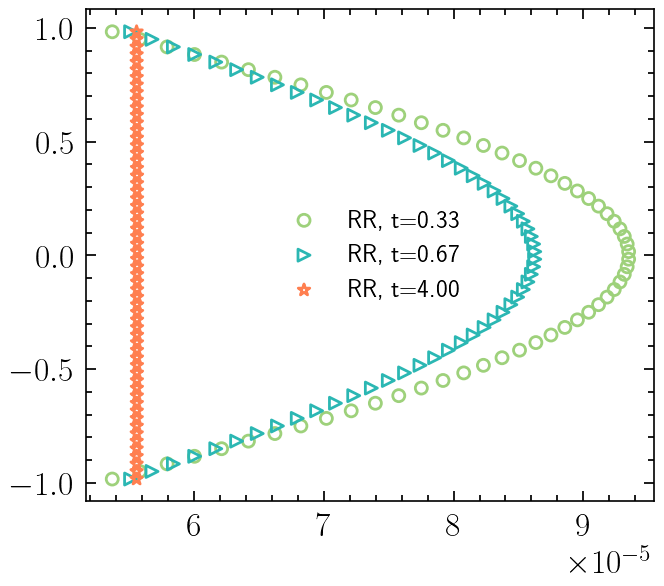

In [15]:
plt.scatter(-ana[:,0]+data_plt_v1[:,10]/u0, x0[:], marker='o', s=75, c='none' , edgecolors= '#9ED17B', linewidths= 2.0, label=f'RR, t={tt[0]:.2f}')
plt.scatter(-ana[:,1]+data_plt_v2[:,10]/u0, x0[:], marker='>', s=75, c='none' , edgecolors= '#2BB7B3', linewidths= 2.0, label=f'RR, t={tt[1]:.2f}')
plt.scatter(-ana[:,2]+data_plt_v3[:,10]/u0, x0[:], marker='*', s=75, c='none' , edgecolors= 'coral', linewidths= 2.0, label=f'RR, t={tt[2]:.2f}')
plt.legend()
plt.show()